In [2]:
import polars as pl
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


Matplotlib is building the font cache; this may take a moment.


O objetivo desta etapa é compreender as características estatísticas do conjunto de dados, identificar padrões relevantes para a modelagem e avaliar a relação entre as variáveis preditoras e a variável alvo (target). Como o objetivo do projeto é prever a direção futura do preço em um horizonte de 15 minutos, a análise será direcionada para identificar possíveis sinais preditivos presentes nas variáveis de microestrutura de mercado.

In [5]:
df = pl.read_parquet(
    "features/ml_features_1m_v2.parquet"
)

print(df.shape)
df.head()

(5587547, 16)


market_id,minute_bar,close_mid,mean_spread,close_spread,bar_volatility,total_volume,buy_volume,sell_volume,trade_count,order_flow_imbalance,target,return_1m,bid_depth,ask_depth,depth_imbalance
str,"datetime[μs, UTC]",f32,f32,f32,f32,f32,f32,f32,u32,f32,i8,f32,f64,f64,f64
"""0x0007deb167d0bb816e2e847a1543…",2026-03-06 00:00:00 UTC,0.285,0.45375,0.45,0.005,0.0,0.0,0.0,0,0.0,0,0.017857,287.79,3845.07,-0.860731
"""0x0007deb167d0bb816e2e847a1543…",2026-03-06 00:01:00 UTC,0.285,0.45,0.45,0.0,0.0,0.0,0.0,0,0.0,0,0.0,287.79,3845.07,-0.860731
"""0x0007deb167d0bb816e2e847a1543…",2026-03-06 00:02:00 UTC,0.29,0.443333,0.44,0.005,0.0,0.0,0.0,0,0.0,0,0.017544,287.79,3845.07,-0.860731
"""0x0007deb167d0bb816e2e847a1543…",2026-03-06 00:03:00 UTC,0.29,0.44,0.44,0.0,0.0,0.0,0.0,0,0.0,0,0.0,287.79,3845.07,-0.860731
"""0x0007deb167d0bb816e2e847a1543…",2026-03-06 00:04:00 UTC,0.29,0.44,0.44,0.0,0.0,0.0,0.0,0,0.0,0,0.0,366.8,8838.88,-0.92031


# Quantas observações e mercados existem?

In [9]:
print(f"Linhas: {df.height:,}")
print(f"Colunas: {df.width}")

df.select(
    pl.col("market_id").n_unique().alias("mercados_unicos")
)

Linhas: 5,587,547
Colunas: 16


mercados_unicos
u32
4710


# Qual o período coberto pelos dados?

In [14]:
# Veificar datas
# Objetivo: Identificar as datas de início e fim do intervalo para planejar a divisão cronológica de treino e teste.
# Resultado: O subconjunto de dados cobre exatamente 6 dias completos, de 06/03/2026 a 11/03/2026.
# Implicação: Ideal para validação inicial (ex: usar os primeiros 4 dias para treino e os 2 últimos para teste).
df.select(
    pl.min("minute_bar").alias("inicio"),
    pl.max("minute_bar").alias("fim")
)

inicio,fim
"datetime[μs, UTC]","datetime[μs, UTC]"
2026-03-06 00:00:00 UTC,2026-03-11 23:59:00 UTC


# Como os dados estão distribuídos ao longo do tempo?

In [10]:
(
    df.select(
        pl.col("minute_bar").dt.date().alias("date")
    )
    .group_by("date")
    .len()
    .sort("date")
)

date,len
date,u32
2026-03-06,1631467
2026-03-07,1570162
2026-03-08,1306097
2026-03-09,440677
2026-03-10,530106
2026-03-11,109038


O volume diário começa alto (~1.6M de linhas no dia 06) e sofre uma redução acentuada a partir do dia 09, atingindo o mínimo no dia 11 (~109k). Essa assimetria indica que mercados foram fechados/resolvidos ou houve uma mudança na coleta. Precisamos garantir que os dias de teste (ex: dias 10 e 11) ainda contenham os mercados principais para uma validação justa.

# Análise da quantidade de observações por mercado.

In [ ]:
print(df.group_by("market_id").len().describe())
df.group_by("market_id").len().sort("len").head()


shape: (9, 3)
┌────────────┬─────────────────────────────────┬─────────────┐
│ statistic  ┆ market_id                       ┆ len         │
│ ---        ┆ ---                             ┆ ---         │
│ str        ┆ str                             ┆ f64         │
╞════════════╪═════════════════════════════════╪═════════════╡
│ count      ┆ 4710                            ┆ 4710.0      │
│ null_count ┆ 0                               ┆ 0.0         │
│ mean       ┆ null                            ┆ 1186.315711 │
│ std        ┆ null                            ┆ 1314.819778 │
│ min        ┆ 0x0007deb167d0bb816e2e847a1543… ┆ 1.0         │
│ 25%        ┆ null                            ┆ 296.0       │
│ 50%        ┆ null                            ┆ 662.0       │
│ 75%        ┆ null                            ┆ 1588.0      │
│ max        ┆ 0xfff145c6201796960cac69aea3f6… ┆ 8221.0      │
└────────────┴─────────────────────────────────┴─────────────┘


market_id,len
str,u32
"""0xaf617e83074e3536fa1b86b1190b…",1
"""0x563ecbc4fcc34f60103e9c5b3354…",3
"""0xb0ea878453eb9c7a835e6820fd35…",3
"""0xec363de4b390604e844387471ab5…",3
"""0xe790b91b38c4d42ecb3e66af723f…",4


Existe grande heterogeneidade entre os mercados. Enquanto alguns possuem apenas 1 observação, outros chegam a mais de 8.000 observações. A mediana é de 662 registros por mercado.  A presença de mercados com histórico muito reduzido sugere a necessidade de avaliar critérios mínimos de observações durante a etapa de modelagem. Será investigado posteriormente o impacto de filtros como len >= 1440 (1 dia completo de negociação) na quantidade total de dados disponíveis.

# Como as variáveis se comportam em termos de média, dispersão e amplitude?

In [11]:
features = [
    "close_mid",
    "mean_spread",
    "close_spread",
    "bar_volatility",
    "total_volume",
    "buy_volume",
    "sell_volume",
    "trade_count",
    "order_flow_imbalance",
    "return_1m",
    "bid_depth",
    "ask_depth",
    "depth_imbalance"
]

df.select(features).describe()

statistic,close_mid,mean_spread,close_spread,bar_volatility,total_volume,buy_volume,sell_volume,trade_count,order_flow_imbalance,return_1m,bid_depth,ask_depth,depth_imbalance
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",5.587547e6,5.587547e6,5.587547e6,5.587547e6,5.587547e6,5.587547e6,5.587547e6,5.587547e6,5.587547e6,5.587547e6,5.587547e6,5.587547e6,5.587547e6
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",0.264384,0.106947,0.105988,0.005248,16.70355,13.900503,2.803048,0.105569,11.097455,0.358244,60529.263125,199718.031162,-0.337332
"""std""",0.280244,0.227499,0.227542,0.031491,862.310974,808.899719,270.595612,1.097412,843.505432,18.620455,144176.553546,1.4187e6,0.557125
"""min""",0.0005,0.000667,0.001,0.0,0.0,0.0,0.0,0.0,-344164.84375,-0.999,0.0,0.0,-1.0
"""25%""",0.0155,0.005,0.005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,486.78,3550.52,-0.843943
"""50%""",0.205,0.015,0.015,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2845.32,17553.28,-0.424224
"""75%""",0.435,0.05,0.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22510.5,90904.98,0.000912
"""max""",0.9995,1.0,1.0,0.9855,680889.0,680884.0,354123.78125,443.0,680879.0,998.999939,5.0261e6,2.1935e7,1.0


# Distribuição do Target

## O problema é balanceado?

In [13]:
print(df.group_by("target").len())

df.group_by("target").len().with_columns(
    (
        pl.col("len") /
        pl.col("len").sum()
    ).alias("proportion")
)

shape: (2, 2)
┌────────┬─────────┐
│ target ┆ len     │
│ ---    ┆ ---     │
│ i8     ┆ u32     │
╞════════╪═════════╡
│ 1      ┆ 1489089 │
│ 0      ┆ 4098458 │
└────────┴─────────┘


target,len,proportion
i8,u32,f64
0,4098458,0.733499
1,1489089,0.266501


A variável alvo apresenta aproximadamente 73% de exemplos da classe 0 e 27% da classe 1, caracterizando um problema desbalanceado.

# Distribuição das Principais Features

In [14]:
df.filter(
    pl.col("order_flow_imbalance") > 1000
).select(
    [
        "buy_volume",
        "sell_volume",
        "total_volume",
        "order_flow_imbalance"
    ]
).head(20)

buy_volume,sell_volume,total_volume,order_flow_imbalance
f32,f32,f32,f32
1110.587891,6.05,1116.637939,1104.537842
1709.925781,0.0,1709.925781,1709.925781
4922.630859,0.0,4922.630859,4922.630859
2623.600342,0.0,2623.600342,2623.600342
1043.23938,0.0,1043.23938,1043.23938
…,…,…,…
2292.519287,0.0,2292.519287,2292.519287
1923.076904,0.0,1923.076904,1923.076904
10217.172852,0.0,10217.172852,10217.172852


A inspeção dos registros revelou que a variável order_flow_imbalance corresponde à diferença bruta entre volume comprador e volume vendedor (buy_volume - sell_volume) e não à versão normalizada descrita na documentação do dataset. Para consertar isso vamos criar uma feature que segue a fórmula (buy_volume - sell_volume)/total_volume

In [17]:
df_eda = df.with_columns(
    pl.when(pl.col("total_volume") > 0)
    .then(
        (pl.col("buy_volume") - pl.col("sell_volume"))
        / pl.col("total_volume")
    )
    .otherwise(0)
    .alias("ofi_normalized")
)

df_eda.select(
    [
        pl.col("ofi_normalized").min().alias("min"),
        pl.col("ofi_normalized").max().alias("max"),
        pl.col("ofi_normalized").mean().alias("mean")
    ]
)


min,max,mean
f32,f32,f32
-1.0,1.0,0.026979


<Figure size 800x400 with 0 Axes>

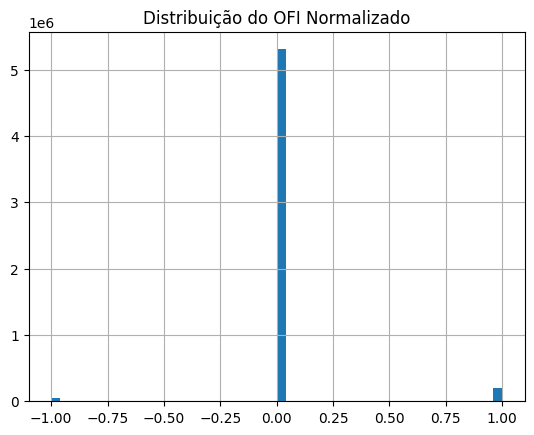

In [18]:
plt.figure(figsize=(8,4))

df_eda.select("ofi_normalized") \
      .to_pandas() \
      .hist(bins=50)

plt.title("Distribuição do OFI Normalizado")
plt.show()

O histograma do OFI comprova que a microestrutura do Polymarket é caracterizada por longos períodos de latência/equilíbrio (concentração massiva em 0.0), intercalados por choques de liquidez unilaterais de alta intensidade (picos em -1.0 e 1.0). Esse comportamento de caudas pesadas e alta concentração central valida a necessidade de algoritmos não-lineares (como árvores de decisão) para capturar os momentos de virada de tendência do mercado.

Um minuto sem negociações significa:
- Baixa liquidez
- Baixo interesse
- Pouca atividade

O eixo horizontal (X) mostra os valores assumidos por order_flow_imbalance. O eixo vertical (Y) mostra a contagem de linhas (frequência)

<Figure size 800x400 with 0 Axes>

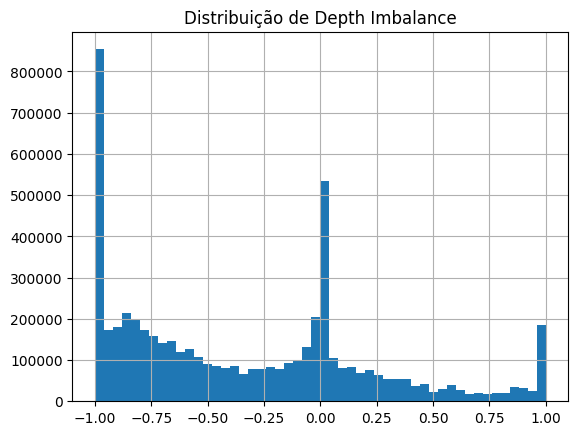

In [16]:
plt.figure(figsize=(8,4))

df.select(
    "depth_imbalance"
).to_pandas().hist(
    bins=50
)

plt.title("Distribuição de Depth Imbalance")
plt.show()

1. Há um pico massivo perto de -1.0 (com mais de 800.000 ocorrências).O que significa: Para o cálculo resultar em $-1.0$, o bid_depth (compradores) é praticamente zero em comparação com o ask_depth (vendedores). O livro está completamente inundado de ordens de venda.

Interpretação Econômica: Muitos mercados de previsão sofrem com falta de liquidez bilateral ou chegam a um ponto onde o resultado do evento fica muito óbvio (ex: um contrato de "SIM" que passa a valer 0.02 dólares porque o evento quase certamente não vai acontecer). Nesses cenários, os compradores desaparecem e sobram apenas ordens de venda massivas empilhadas no livro.


2. Repare que o lado esquerdo do gráfico é visivelmente mais alto e volumoso do que o lado direito.

O que significa: Existe uma tendência geral, na média histórica desses dados, de o livro ter mais profundidade de venda (ask_depth) do que de compra (bid_depth).

Interpretação Econômica: Isso indica que muitos criadores de mercado (market makers) ou apostadores preferem deixar suas posições limitadas de vendas abertas, gerando uma pressão vendedora estrutural na base. No Polymarket, os robôs preferem operar como grandes lojas de departamentos (vendedores) do que como clientes (compradores). Eles enchem as prateleiras com ordens de venda pendentes porque é estatisticamente mais seguro coletar os centavos dos apostadores do que tentar adivinhar o futuro comprando contratos. É por isso que o seu gráfico de depth_imbalance pende tanto para o lado negativo (venda)!

Outro motivo: Pense em como as pessoas apostam. Se você comprou um contrato por 20 centavos achando que um evento ia acontecer, e o evento começa a dar errado, você não consegue simplesmente clicar em um botão e sumir com o contrato. Você é obrigado a colocá-lo à venda no livro de ofertas por um preço baixo (tipo 15 centavos) e ficar esperando sentada até que algum corajoso apareça para comprar.

Como muita gente desiste das apostas ou tenta "mudar de lado", o livro de ofertas vira um grande estoque parado de pessoas tentando se livrar de contratos antigos

3. Existe um pico isolado exatamente em 0.0 (com cerca de 500.000 ocorrências).

O que significa: Significa que bid_depth é exatamente igual a ask_depth.

Interpretação Econômica: São os momentos de equilíbrio perfeito ou, mais provável no Polymarket, momentos em que robôs de liquidez (algoritmos de arbitragem) colocam ordens perfeitamente espelhadas de compra e venda com tamanhos idênticos em mercados eficientes.

4. No extremo direito, há um pico modesto perto de +1.0.O que significa: O livro ficou sem nenhuma ordem de venda significativa e foi tomado por intenções de compra.Interpretação Econômica: Representa momentos de forte convicção de alta de um contrato, mas que ocorre com muito menos frequência do que o colapso para o lado vendedor (por isso o pico do $+1.0$ é bem menor do que o do $-1.0$).

<Figure size 800x400 with 0 Axes>

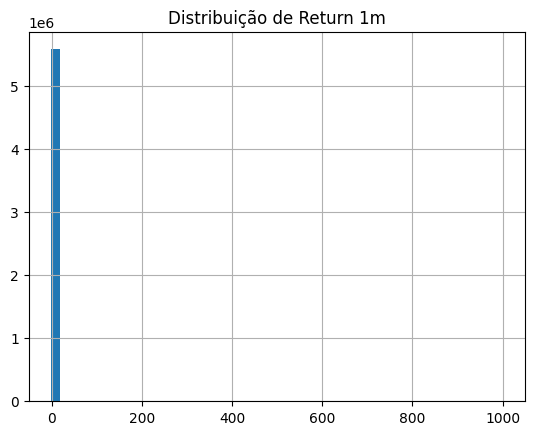

In [17]:
plt.figure(figsize=(8,4))

df.select(
    "return_1m"
).to_pandas().hist(
    bins=50
)

plt.title("Distribuição de Return 1m")
plt.show()

<Figure size 800x400 with 0 Axes>

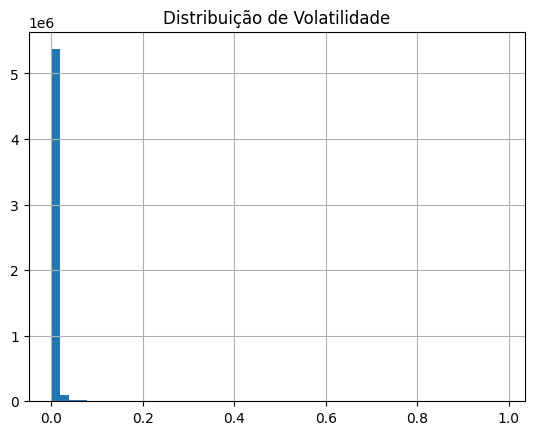

In [18]:
plt.figure(figsize=(8,4))

df.select(
    "bar_volatility"
).to_pandas().hist(
    bins=50
)

plt.title("Distribuição de Volatilidade")
plt.show()

# Comparação das Features por Classe

### Mercados que sobem possuem características diferentes dos que não sobem?

In [19]:
df.group_by("target").agg(
    [
        pl.col("order_flow_imbalance").mean(),
        pl.col("depth_imbalance").mean(),
        pl.col("return_1m").mean(),
        pl.col("bar_volatility").mean(),
        pl.col("total_volume").mean()
    ]
)

target,order_flow_imbalance,depth_imbalance,return_1m,bar_volatility,total_volume
i8,f32,f64,f32,f32,f32
1,12.629087,0.137799,0.001769,0.007531,22.069132
0,10.540968,-0.50996,0.487762,0.004418,14.754079


In [20]:
df.group_by("target").agg(
    [
        pl.col("order_flow_imbalance").median(),
        pl.col("depth_imbalance").median(),
        pl.col("return_1m").median(),
        pl.col("bar_volatility").median()
    ]
)

target,order_flow_imbalance,depth_imbalance,return_1m,bar_volatility
i8,f32,f64,f32,f32
0,0.0,-0.649152,0.0,0.0
1,0.0,0.013235,0.0,0.0


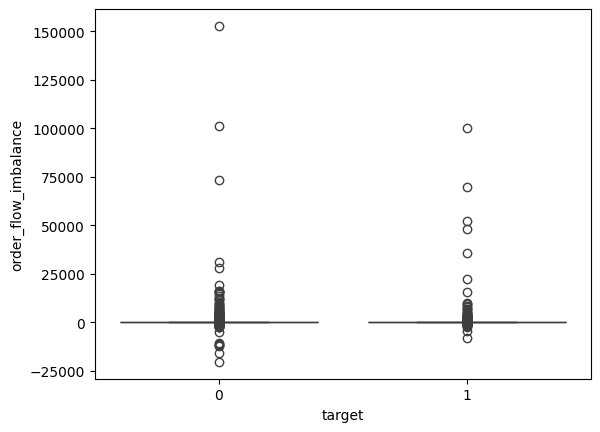

In [29]:
sample = (
    df.select(
        ["target", "order_flow_imbalance"],      
    )
    .sample(
        n=100000,
        seed=42
    )
    .to_pandas()
)

sns.boxplot(
    data=sample,
    x="target",
    y="order_flow_imbalance"
)

plt.show()

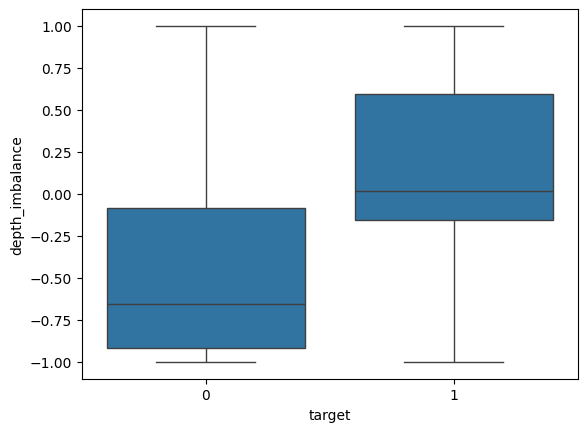

In [30]:
sample = (
    df.select(
        ["target", "depth_imbalance"],      
    )
    .sample(
        n=100000,
        seed=42
    )
    .to_pandas()
)

sns.boxplot(
    data=sample,
    x="target",
    y="depth_imbalance"
)

plt.show()

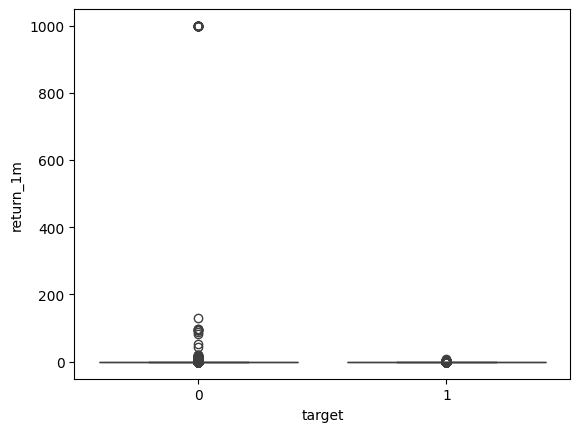

In [31]:
sample = (
    df.select(
        ["target", "return_1m"],      
    )
    .sample(
        n=100000,
        seed=42
    )
    .to_pandas()
)

sns.boxplot(
    data=sample,
    x="target",
    y="return_1m"
)

plt.show()

# Correlação entre amostras

In [32]:
sample_corr = (
    df.select(
        features + ["target"]
    )
    .sample(
        n=100000,
        seed=42
    )
    .to_pandas()
)

In [33]:
corr = sample_corr.corr()

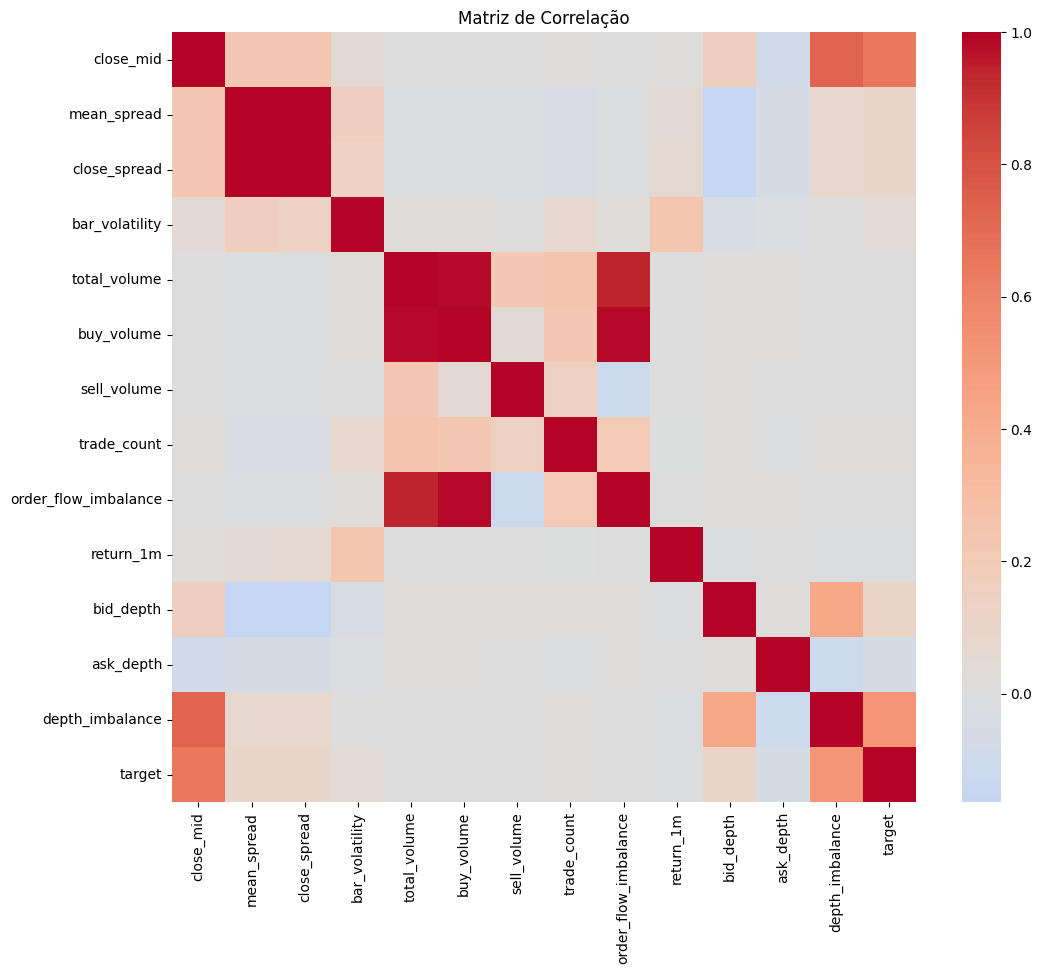

In [34]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de Correlação")
plt.show()

In [35]:
corr["target"].sort_values()

ask_depth              -0.058752
return_1m              -0.010443
sell_volume             0.001541
order_flow_imbalance    0.004803
buy_volume              0.005098
total_volume            0.005234
trade_count             0.013759
bar_volatility          0.045544
close_spread            0.091118
mean_spread             0.092764
bid_depth               0.116022
depth_imbalance         0.514100
close_mid               0.649636
target                  1.000000
Name: target, dtype: float64

# Mercados mais líquidos

In [36]:
(
    df.group_by("market_id")
      .agg(
          pl.col("total_volume").sum()
      )
      .sort(
          "total_volume",
          descending=True
      )
      .head(10)
)

market_id,total_volume
str,f32
"""0xe492ad958b21201e928b66665708…",3.6908e6
"""0xf18253f5c0b0ffc42172a435892b…",3.5688e6
"""0xfc7fb7e4550f39b1a4059b233b33…",3349585.5
"""0xb70468bb7e635f836a72ae302c1e…",1.9008e6
"""0xabe1486b141aac413c96286eb3e4…",1646303.5
"""0xc6c7ccbb4d0e7d0ee813522f4063…",1.5459e6
"""0xca79771f582632406946bea87d59…",1.4612e6
"""0x9fc89f8e8bc61a232451064d15a3…",1.4608e6
"""0x31743c7bb0f88d9399e67cb1b553…",1.3525e6
